In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('cleaned_ecommerce_churn.csv')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


# E-Commerce Churn — EDA

## Key Findings:

- 16.84% of customers in the dataset churned.

- Churn is higher among customers with tenure less than ~10 months and those who haven't ordered recently are more likely to churn..

- Customers who complained churn at 31.67, compared to 10.91 for those who did not complain.

- City Tier 3 shows the highest churn rate among all tiers.

- Certain login devices phone have higher churn rates.

- - Lower satisfaction scores are associated with higher churn.

In [3]:
df.groupby('CityTier')['Churn'].mean()

CityTier
1    0.145117
2    0.198347
3    0.213705
Name: Churn, dtype: float64

<Axes: xlabel='CityTier'>

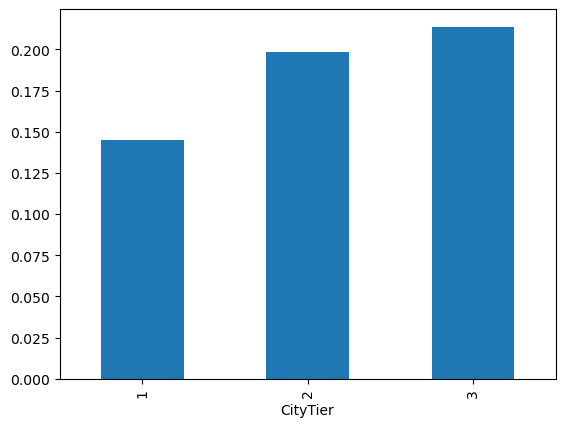

In [4]:
df.groupby('CityTier')['Churn'].mean().plot(kind='bar')

Customers from lower city tiers show higher churn rates compared to higher-tier cities.

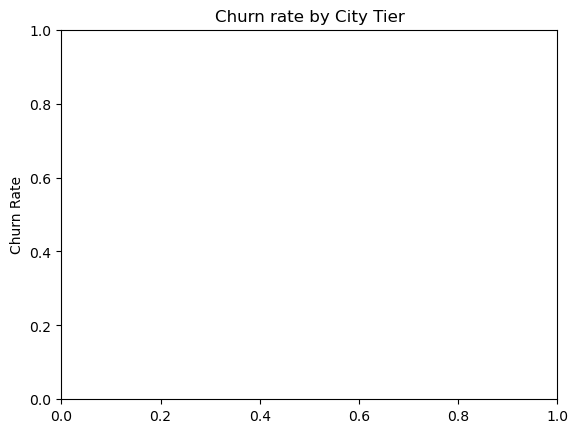

In [7]:
plt.title('Churn rate by City Tier')
plt.ylabel('Churn Rate')
plt.show()

In [8]:
print(df.shape)

(5630, 20)


In [9]:
print(df.columns)

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='str')


In [10]:
df.groupby('CityTier')['Churn'].mean()

CityTier
1    0.145117
2    0.198347
3    0.213705
Name: Churn, dtype: float64

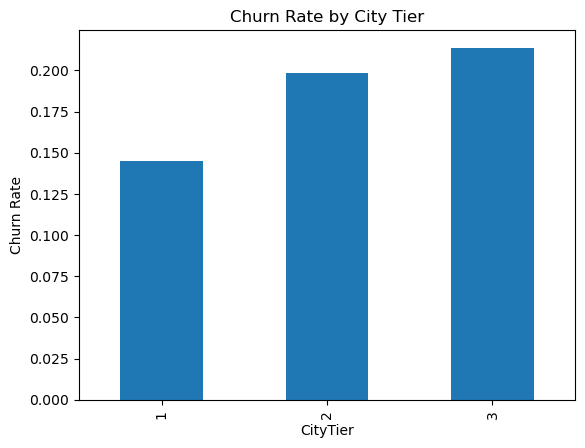

In [11]:
df.groupby('CityTier')['Churn'].mean().plot(kind='bar')
plt.title('Churn Rate by City Tier')
plt.ylabel('Churn Rate')
plt.show()

In [12]:
df.groupby('PreferredLoginDevice')['Churn'].mean()

PreferredLoginDevice
Computer        0.198286
Mobile Phone    0.125859
Phone           0.224208
Name: Churn, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

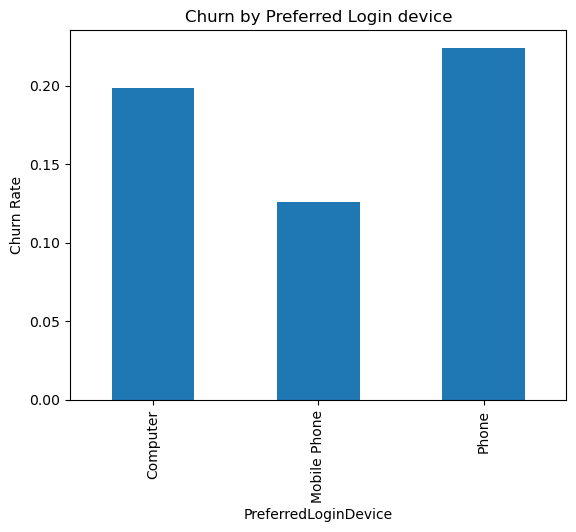

In [14]:
df.groupby('PreferredLoginDevice')['Churn'].mean().plot(kind='bar')
plt.title('Churn by Preferred Login device')
plt.ylabel('Churn Rate')
plt.show

Customers using mobile devices exhibit higher churn compared to other devices.

plt.figure(flagsize=(12,8))

In [16]:
plt.figure(figsize=(12,8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

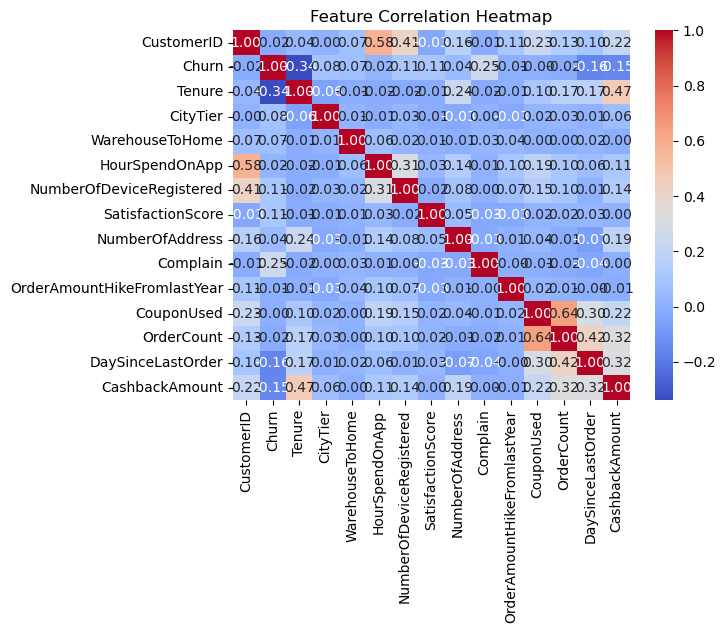

In [18]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            fmt='.2f',
            cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

Customers with lower tenure are more likely to churn compared to long-term customers.

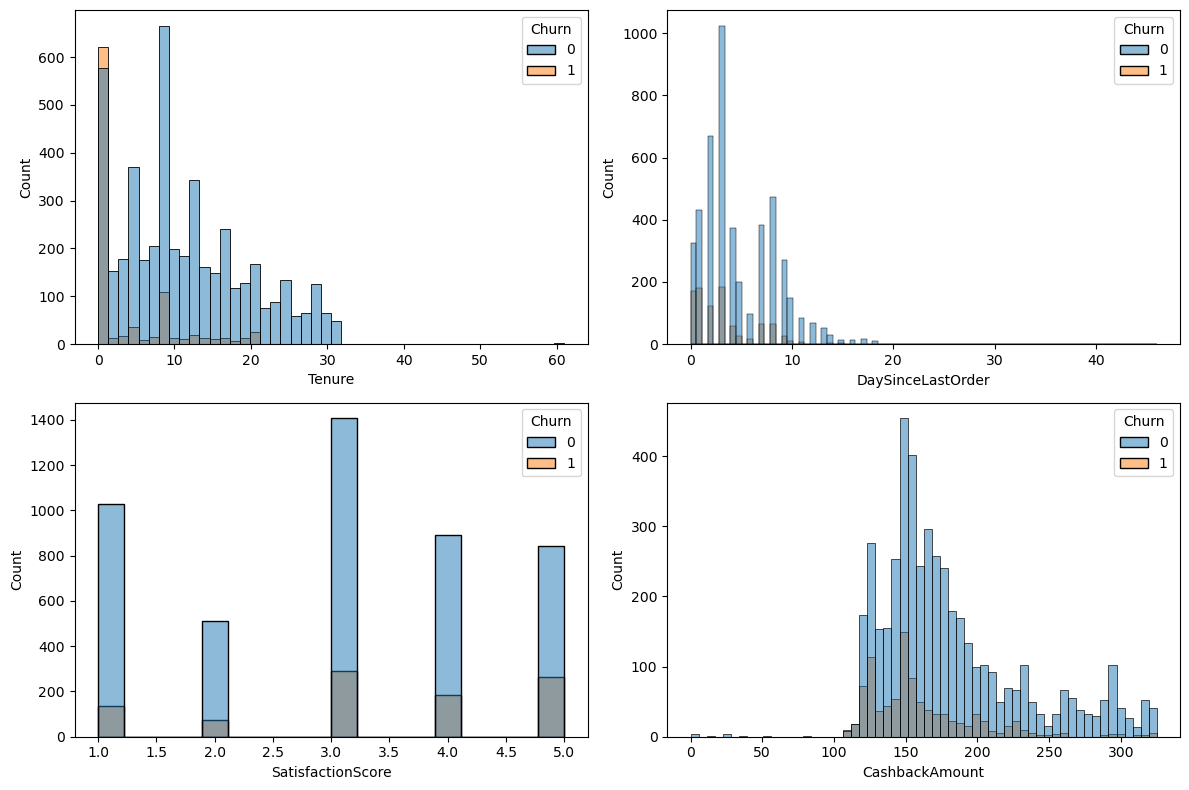

In [21]:
fig,axes=plt.subplots(2,2,figsize=(12,8))
sns.histplot(data=df, x='Tenure', hue='Churn',ax=axes[0,0])
sns.histplot(data=df, x='DaySinceLastOrder', hue='Churn', ax=axes[0,1])
sns.histplot(data=df, x='SatisfactionScore', hue='Churn', ax=axes[1,0])
sns.histplot(data=df, x='CashbackAmount', hue='Churn', ax=axes[1,1])

plt.tight_layout()
plt.show()

Customers with lower tenure and those who have not ordered recently show a higher likelihood of churn. Additionally, churned customers tend to have lower satisfaction scores, while cashback amount does not show a strong impact on churn behavior.

In [23]:
df.groupby('Complain')['Churn'].mean()

Complain
0    0.109290
1    0.316708
Name: Churn, dtype: float64

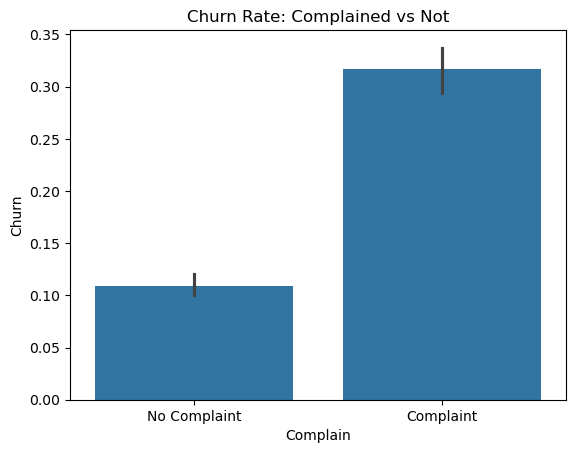

In [27]:
sns.barplot(x='Complain',y='Churn',data=df)
plt.title('Churn Rate: Complained vs Not')
plt.xticks([0,1],['No Complaint','Complaint'])
plt.show()

Customers who raised complaints have a significantly higher churn rate than those who did not.

In [30]:
df['Churn'].mean() * 100

np.float64(16.838365896980463)

In [31]:
df.groupby('Complain')['Churn'].mean() * 100

Complain
0    10.928962
1    31.670823
Name: Churn, dtype: float64

In [32]:
df.groupby('CityTier')['Churn'].mean() * 100

CityTier
1    14.511729
2    19.834711
3    21.370499
Name: Churn, dtype: float64